# Comparison of SVM and Deep Learning Models

H3_7 is the best performing spatial unit for the Neural Network and the second best for SVM. For the NN it is the hourly level and for the SVM it is the daily level though. We will compare the models for both temporal levels against each other and the base line on the test set.

Rather than re-loading and re-running the models, this notebook loads only their already-computed predictions on the held-out
test split plus the historical-mean baseline.

All three signals (baseline, SVM, NN) live as columns of a single testing_df, so each cell is just a different slice/aggregation of that one frame.

In [18]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import h3
import geopandas as gpd
import contextily as ctx
import shapely
import mapclassify
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", message="Mean of empty slice")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

INDEX = "h3_index_7"
TRUTH = "y_true"
BASELINE_COL = "base_demand"

SVR_DIR = Path("../models_predictions/SVR/residual/predictions")
FNN_DIR = Path("../models_predictions/FNN/standard/h3_7")

predictions = {
    "svm": {"col": "y_pred_svr", "name": "Best SVM (Residual SVR)"},
    "nn": {"col": "y_pred_fnn", "name": "Neural Network (FNN)"},
}

def score(y_true, y_pred, name):
    return {
        "Model": name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
    }

def load_comparison(temporal):
    svr = pd.read_parquet(SVR_DIR / f"test_pred_h3_7_{temporal}.parquet")
    fnn = pd.read_parquet(FNN_DIR / f"FNN_h3_7_{temporal}.parquet")
    svr.rename(columns={"Total_Trip_Start": "y_true", "SVR_pred": "y_pred"}, inplace=True)
    return svr.merge(fnn, on=[INDEX, "timestamp", "y_true"], suffixes=("_svr", "_fnn"))

comparisons = {
    "daily": load_comparison("daily"),
    "hourly": load_comparison("hourly"),
}

print("Loaded:")
for temporal, df in comparisons.items():
    print(f"h3_7/{temporal}: {len(df)} rows")

Loaded:
h3_7/daily: 24068 rows
h3_7/hourly: 643069 rows


## Performance Metrics Table

Historical-mean baseline (`base_demand`) plus the best SVM and the neural network, scored on the
full `h3_7/daily` held-out **test** set.

In [19]:
#| label: tbl-svm-vs-nn-overall
#| fig-cap: "Overall TEST performance at h3_7/daily and h3_7/hourly."
for temporal, testing_df in comparisons.items():
    print(f"\n H3_7/{temporal}")
    rows = [score(testing_df[TRUTH].values, testing_df[BASELINE_COL].values, "Baseline")]
    for p in predictions.values():
        rows.append(score(testing_df[TRUTH].values, testing_df[p["col"]].values, p["name"]))
    display(pd.DataFrame(rows).set_index("Model").round(4))


 H3_7/daily


,MAE,RMSE,R2
Model,,,
Baseline,0.7560,6.4347,-0.4454
Best SVM (Residual SVR),0.8016,5.9423,-0.2327
Neural Network (FNN),0.6726,3.4963,0.5733



 H3_7/hourly


,MAE,RMSE,R2
Model,,,
Baseline,0.1954,1.7027,0.3586
Best SVM (Residual SVR),0.2537,1.6874,0.3701
Neural Network (FNN),0.1828,1.3591,0.5914


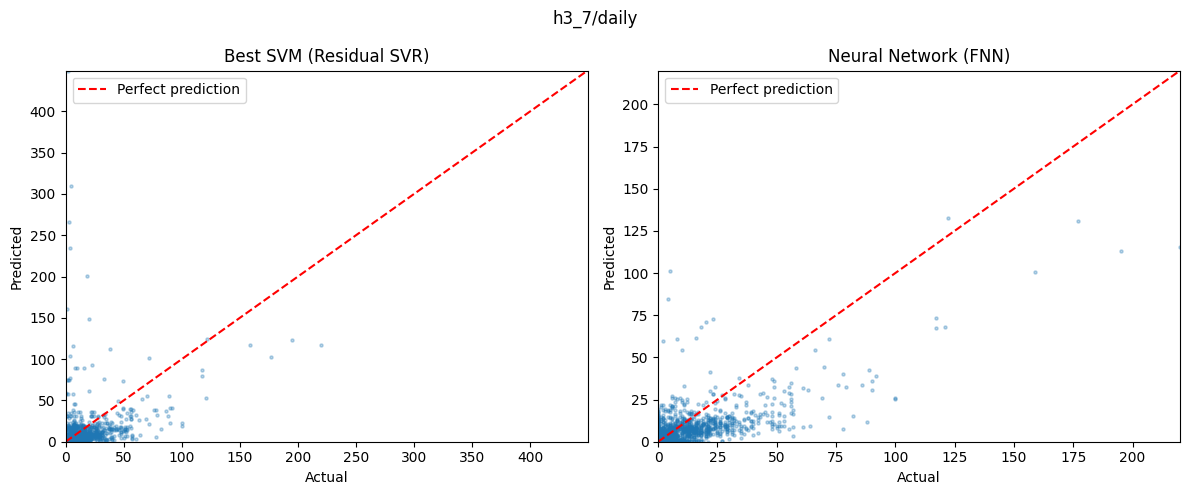

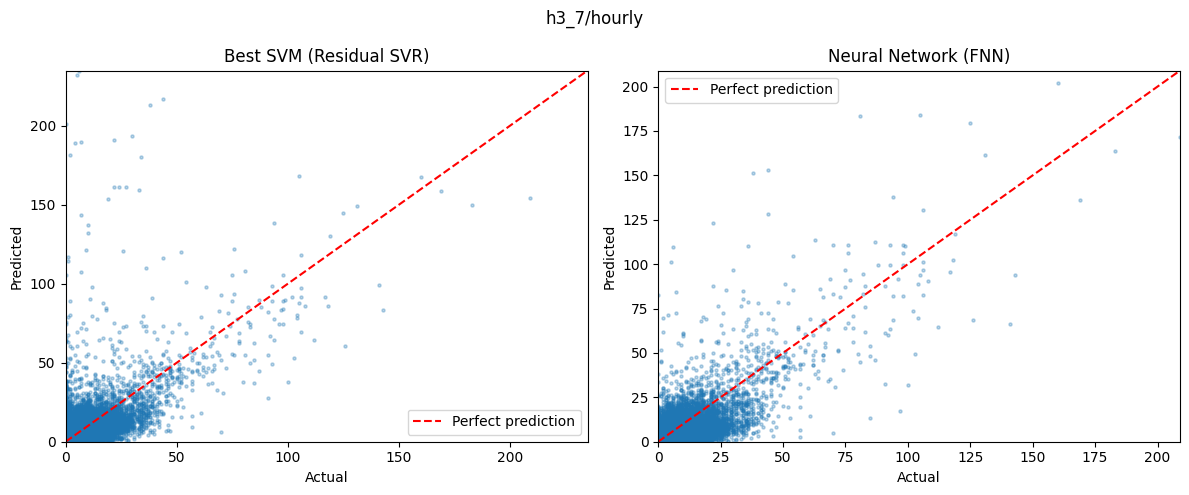

In [20]:
#| label: fig-svm-vs-nn-scatter
#| fig-cap: "Actual vs. predicted demand per temporal resolution."
for temporal, testing_df in comparisons.items():
    y_true = testing_df[TRUTH].values
    fig, axes = plt.subplots(1, len(predictions), figsize=(6 * len(predictions), 5), squeeze=False)
    fig.suptitle(f"h3_7/{temporal}")
    for ax, (key, p) in zip(axes[0], predictions.items()):
        pred = testing_df[p["col"]].values
        lim = max(y_true.max(), pred.max())
        ax.scatter(y_true, pred, alpha=0.3, s=5)
        ax.plot([0, lim], [0, lim], "r--", label="Perfect prediction")
        ax.set_xlim(0, lim)
        ax.set_ylim(0, lim)
        ax.set_xlabel("Actual")
        ax.set_ylabel("Predicted")
        ax.set_title(p["name"])
        ax.legend()
    plt.tight_layout()
    plt.show()

## Spatial Prediction Quality

The aggregate metrics above collapse the whole city into a single number and hide strong
**spatial** variation in how well each model performs. Here we aggregate error by H3 hexagon and
compare whichever of the SVM / the neural network are available, side by side.

- **MAE per hexagon**: The absolute size of the prediction miss (trips/day).
- **Relative error per hexagon**: The miss size relative to that cell's own mean demand.
- **R² per hexagon** How much of each cell's day-to-day demand variation the model explains. (Cells whose demand is essentially flat have no variation to explain, so their R² is undefined and they are greyed out.)

In [21]:
# Community area outlines, used as a spatial reference overlay in the choropleths.
tracts = gpd.read_file(Path("..") / "data" / "chicago_census_comm.gpkg")
community_areas = tracts.dissolve(by="commarea")


def get_hexagon_grid(data, h3_col="h3_index"):
    """Build a GeoDataFrame of H3 hexagon polygons, preserving all columns from the source."""
    def _to_polygon(cell):
        boundary = h3.cell_to_boundary(cell)
        return shapely.geometry.Polygon([(lng, lat) for lat, lng in boundary])

    if isinstance(data, pd.Series):
        df = pd.DataFrame({"h3_index": list(data)})
        h3_list = df["h3_index"]
    else:
        df = data.reset_index(drop=True)
        h3_list = df[h3_col]
    geometries = [_to_polygon(c) for c in h3_list]
    return gpd.GeoDataFrame(df, geometry=geometries, crs="EPSG:4326")


def get_hexagon_performance_metrics(df_eval, pred_col, target_col=TRUTH, h3_col="h3_index_7"):
    """Compute MAE/RMSE/R2/relative-error per hexagon for one prediction column."""
    d = df_eval.assign(
        abs_err=(df_eval[target_col] - df_eval[pred_col]).abs(),
        sq_err=(df_eval[target_col] - df_eval[pred_col]) ** 2,
    )
    grp = d.groupby(h3_col)
    hex_perf = grp.agg(
        n_obs=(target_col, "size"),
        mean_actual=(target_col, "mean"),
        var_actual=(target_col, "var"),
        mae=("abs_err", "mean"),
        mse=("sq_err", "mean"),
    )
    hex_perf["rmse"] = np.sqrt(hex_perf["mse"])
    ss_res = grp["sq_err"].sum()
    ss_tot = hex_perf["var_actual"].fillna(0) * (hex_perf["n_obs"] - 1)
    hex_perf["r2"] = 1 - ss_res / ss_tot.replace(0, np.nan)
    hex_perf["rel_error"] = hex_perf["mae"] / hex_perf["mean_actual"].replace(0, np.nan)
    hex_perf = hex_perf.drop(columns=["var_actual", "mse"]).reset_index()
    hex_perf_gdf = get_hexagon_grid(hex_perf, h3_col=h3_col)
    return hex_perf, hex_perf_gdf


def shared_quantile_bins(gdfs, value_col, k=7):
    """Quantile bin edges pooled over every gdf's `value_col`, so all subplots in a figure share
    one classification (identical colors + legend) and are directly comparable."""
    pooled = pd.concat([gdf[value_col] for gdf in gdfs]).replace([np.inf, -np.inf], np.nan).dropna()
    return mapclassify.Quantiles(pooled, k=k).bins


def create_choropleth_plot(ax, gdf, value_col, title="", cmap="YlOrRd", k=7, bins=None):
    """Plot one quantile choropleth of a hexagon-level metric onto ax, with a Chicago basemap and
    community-area boundary overlay. Pass `bins` (from `shared_quantile_bins`) to force a fixed
    classification shared across subplots so their legends line up for comparison."""
    if bins is not None:
        scheme_kwds = dict(scheme="UserDefined", classification_kwds={"bins": list(bins)})
    else:
        scheme_kwds = dict(scheme="quantiles", k=k)
    gdf.to_crs(epsg=3857).plot(
        ax=ax, column=value_col, cmap=cmap,
        edgecolor="none", alpha=0.8, legend=True, zorder=1,
        legend_kwds=dict(title=value_col.replace("_", " ").title(),
                         loc="lower right", fontsize=8, title_fontsize=9),
        missing_kwds=dict(color="lightgrey", label="No data"),
        **scheme_kwds,
    )
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.PositronNoLabels, zoom=11)
    community_areas.to_crs(epsg=3857).boundary.plot(ax=ax, color="#222", linewidth=1.0, alpha=0.9, zorder=3)
    ax.set_axis_off()
    ax.set_title(title, fontsize=12, fontweight="bold", pad=10)

In [22]:
# (hex_perf, hex_gdf) per model, keyed the same way as `predictions`. Computed on the test set.
hex_data = {key: get_hexagon_performance_metrics(testing_df, pred_col=p["col"], h3_col="h3_index_7")
           for key, p in predictions.items()}

### Map 1: mean absolute error (MAE) per hexagon

Because demand itself is far higher downtown, the largest absolute errors concentrate in the Loop;
the quiet outskirts have tiny MAE simply because there is little demand.


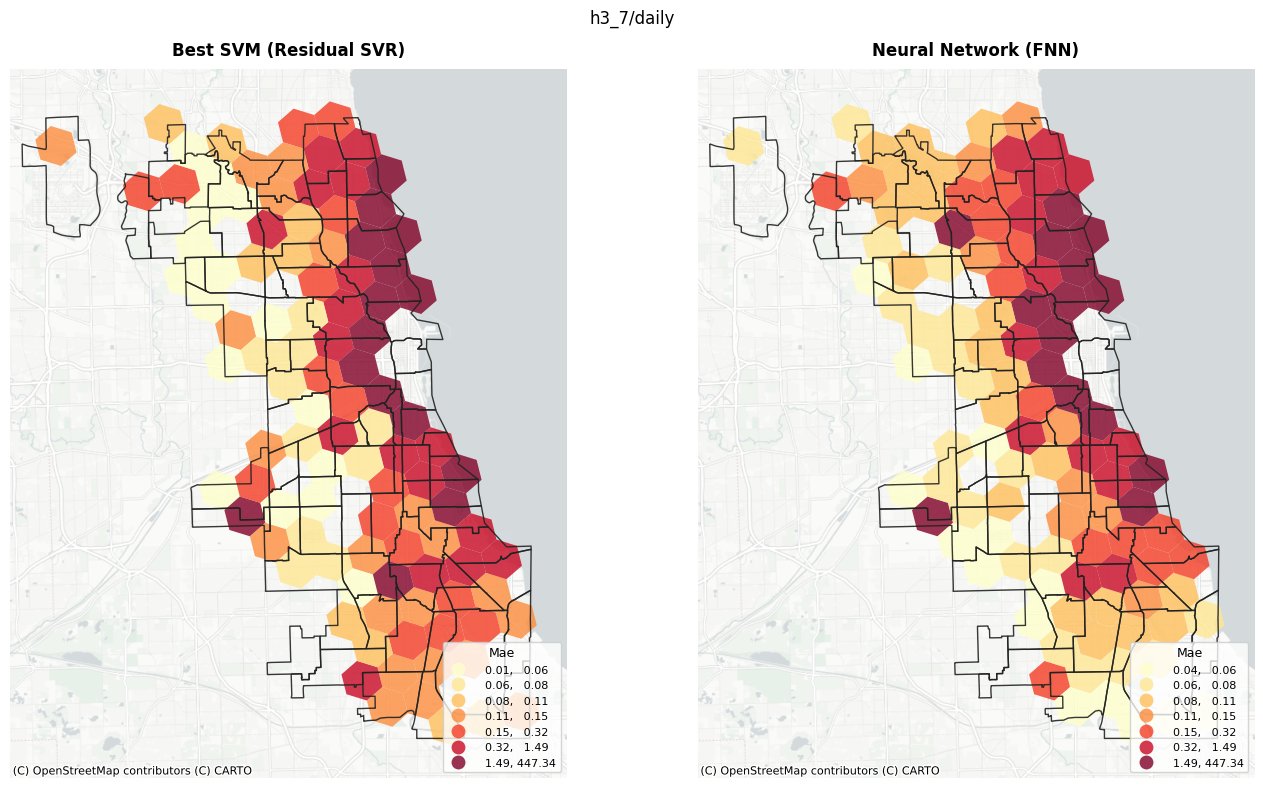

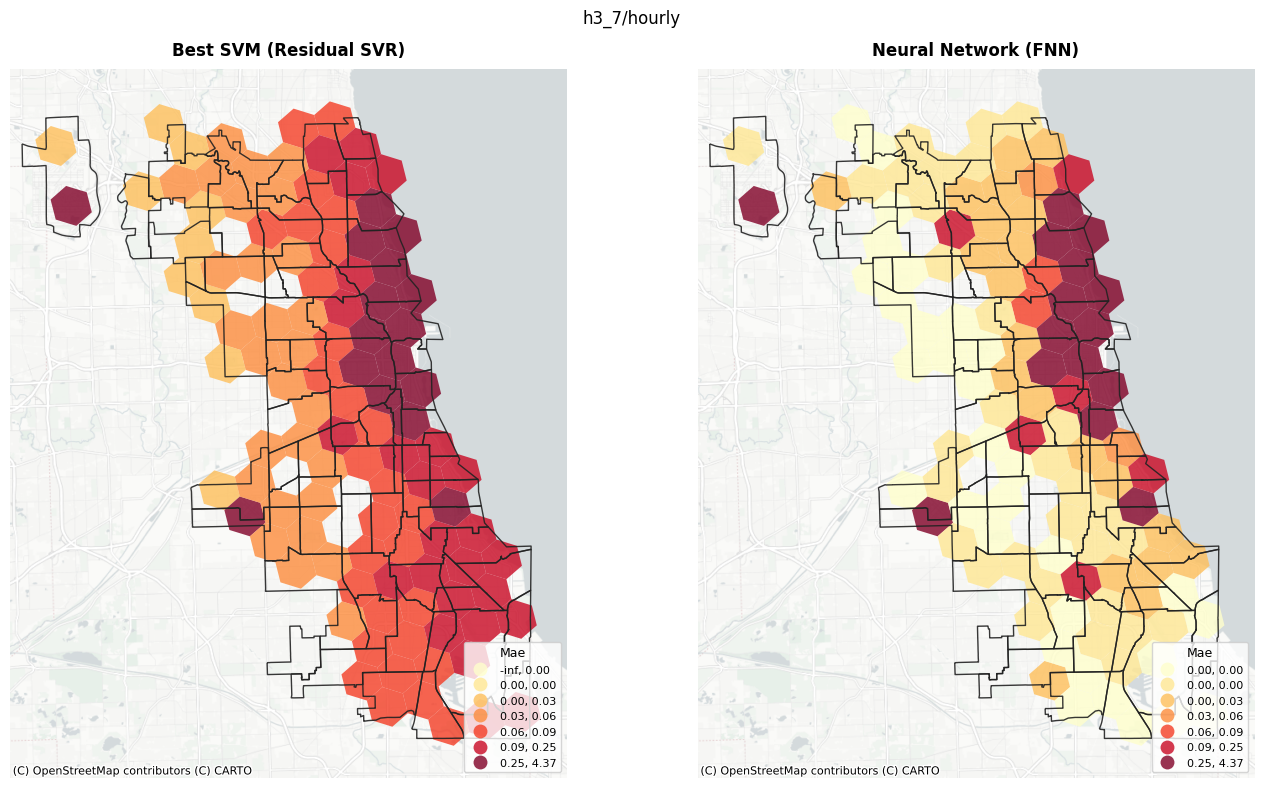

In [23]:
#| label: fig-svm-hex-mae
#| fig-cap: "MAE per hexagon per temporal resolution."
for temporal, testing_df in comparisons.items():
    hex_data = {key: get_hexagon_performance_metrics(testing_df, pred_col=p["col"], h3_col=INDEX)
                for key, p in predictions.items()}
    bins = shared_quantile_bins([gdf for (_, gdf) in hex_data.values()], "mae")
    fig, axes = plt.subplots(1, len(hex_data), figsize=(7 * len(hex_data), 8), squeeze=False)
    fig.suptitle(f"h3_7/{temporal}")
    for ax, (key, (_, gdf)) in zip(axes[0], hex_data.items()):
        create_choropleth_plot(ax, gdf, "mae", title=predictions[key]["name"], bins=bins)
    plt.tight_layout()
    plt.show()


### Map 2: mean relative error (MRE) per hexagon

The miss size relative to each cell's own mean demand -- this is what makes small-demand
outskirts visible instead of always looking "perfect" on raw MAE alone.


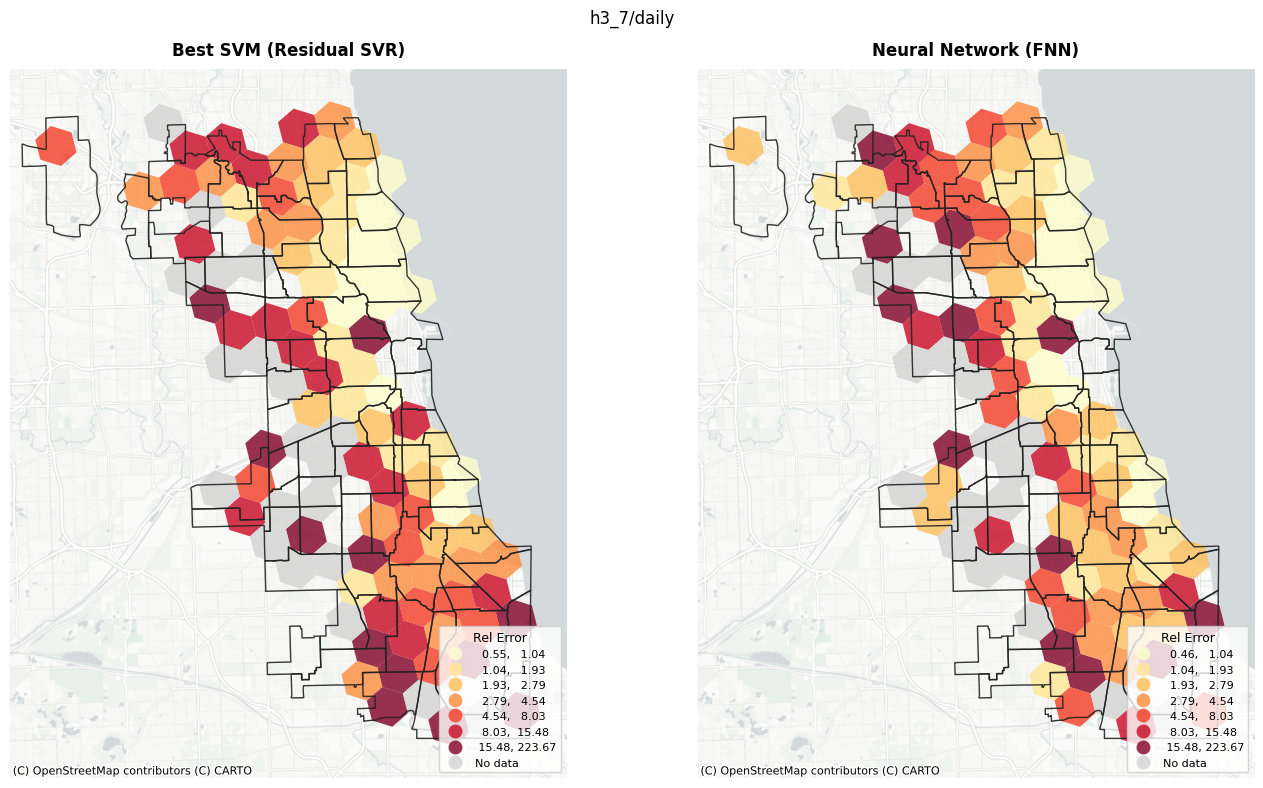

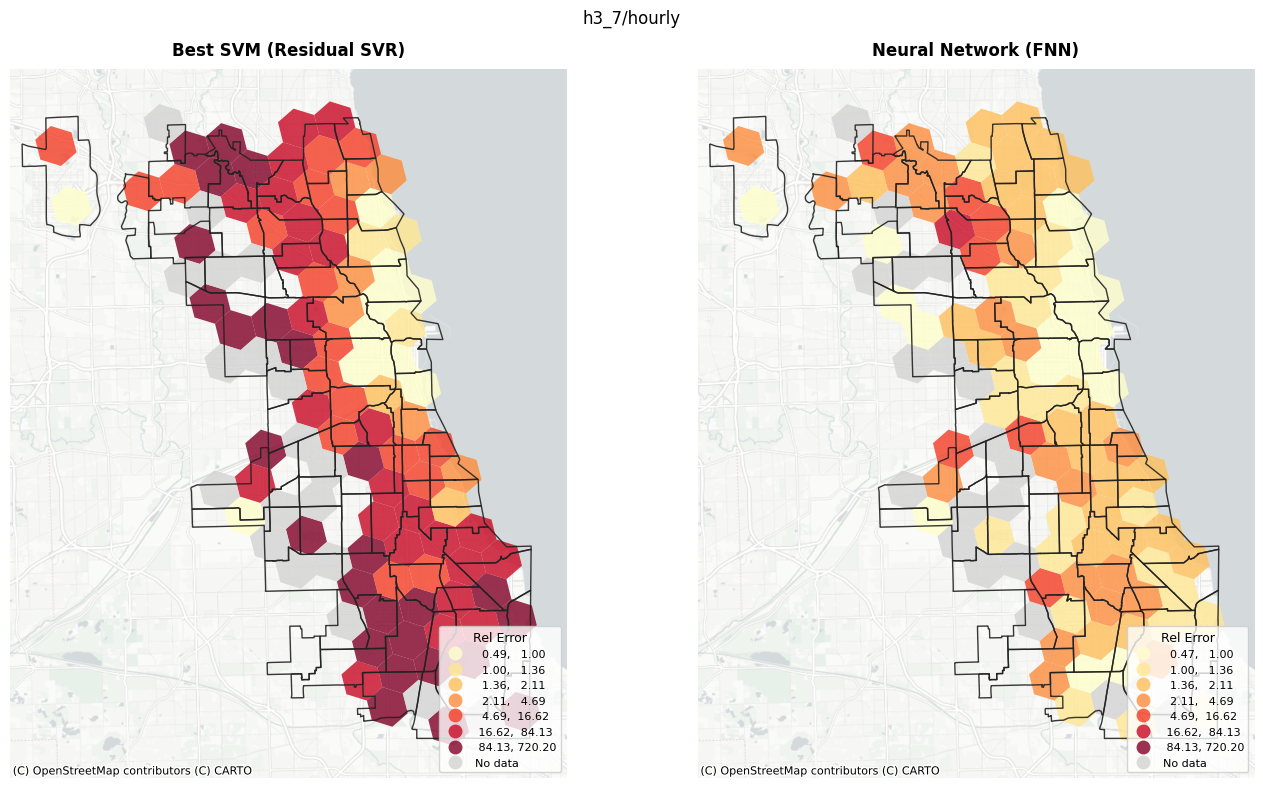

In [24]:
#| label: fig-svm-hex-mre
#| fig-cap: "Relative error per hexagon per temporal resolution."
for temporal, testing_df in comparisons.items():
    hex_data = {key: get_hexagon_performance_metrics(testing_df, pred_col=p["col"], h3_col=INDEX)
                for key, p in predictions.items()}
    bins = shared_quantile_bins([gdf for (_, gdf) in hex_data.values()], "rel_error")
    fig, axes = plt.subplots(1, len(hex_data), figsize=(7 * len(hex_data), 8), squeeze=False)
    fig.suptitle(f"h3_7/{temporal}")
    for ax, (key, (_, gdf)) in zip(axes[0], hex_data.items()):
        create_choropleth_plot(ax, gdf, "rel_error", title=predictions[key]["name"], bins=bins)
    plt.tight_layout()
    plt.show()


### Map 3: coefficient of determination (R2) per hexagon

Green = the day-to-day demand pattern is captured well; red = poorly; grey = too little demand
variation to assess.


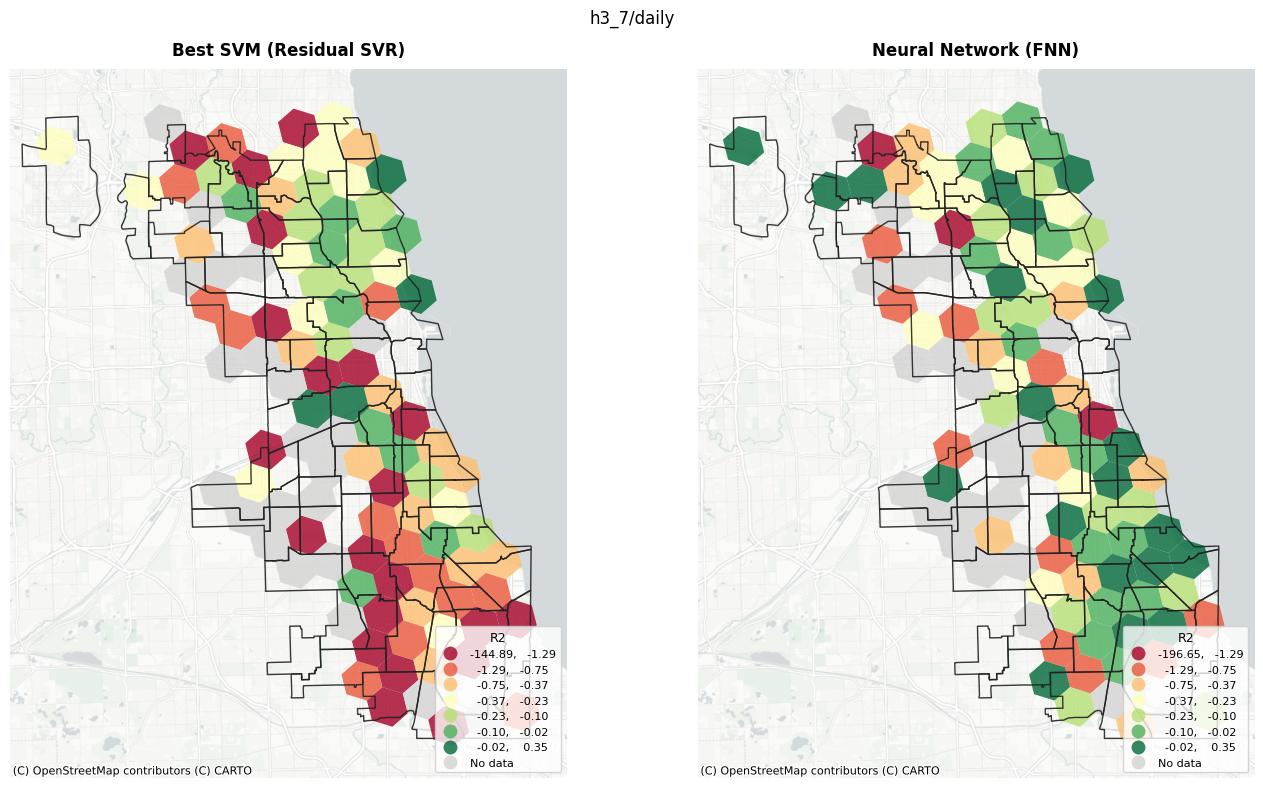

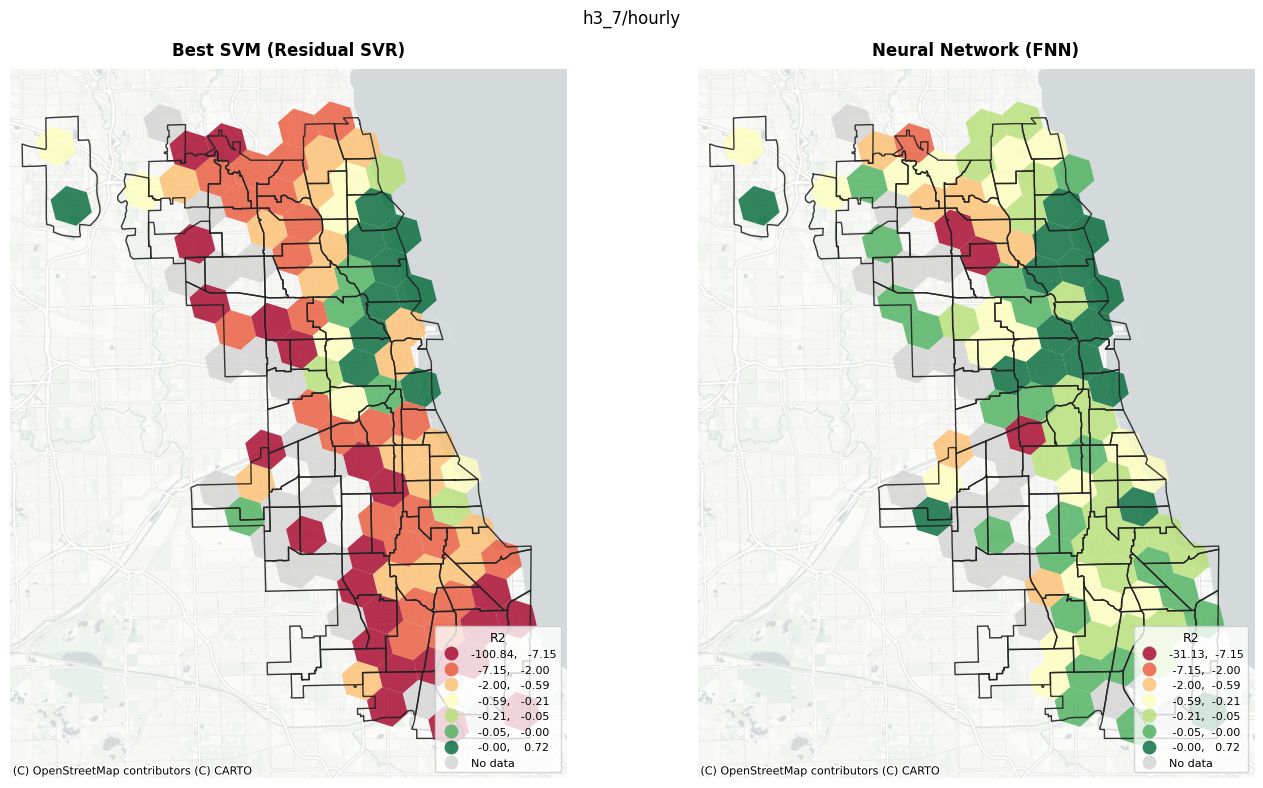

In [25]:
#| label: fig-svm-hex-r2
#| fig-cap: "R² per hexagon per temporal resolution."
for temporal, testing_df in comparisons.items():
    hex_data = {key: get_hexagon_performance_metrics(testing_df, pred_col=p["col"], h3_col=INDEX)
                for key, p in predictions.items()}
    bins = shared_quantile_bins([gdf for (_, gdf) in hex_data.values()], "r2")
    fig, axes = plt.subplots(1, len(hex_data), figsize=(7 * len(hex_data), 8), squeeze=False)
    fig.suptitle(f"h3_7/{temporal}")
    for ax, (key, (_, gdf)) in zip(axes[0], hex_data.items()):
        create_choropleth_plot(ax, gdf, "r2", title=predictions[key]["name"], cmap="RdYlGn", bins=bins)
    plt.tight_layout()
    plt.show()


### Map 4: where does one model beat the other?

The three maps above put the SVM and the NN side by side, but reading "who wins where" off two separate color scales is hard. This map plots the difference directly:

`MAE_NN - MAE_SVM` per hexagon. 
**Blue means the SVM has the lower error there (SVM wins); Red means the NN does.**

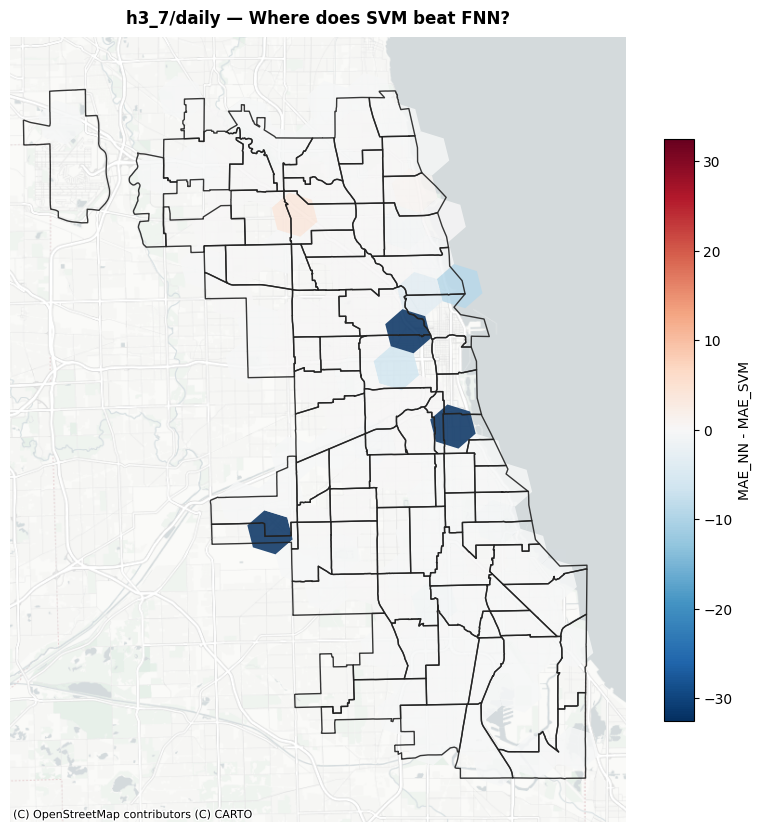

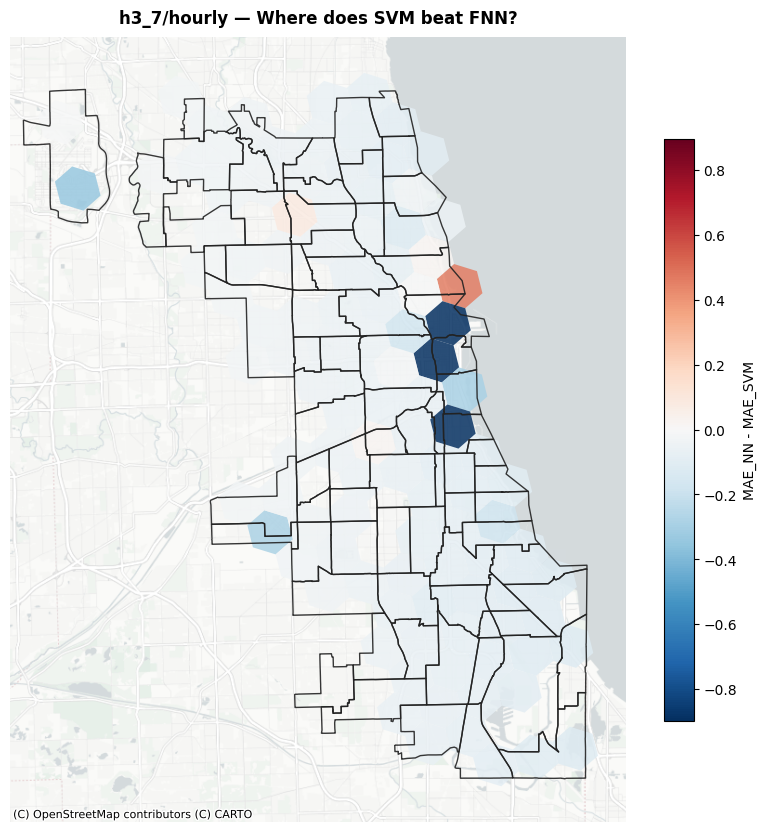

In [26]:
#| label: fig-svm-vs-nn-hex-delta
#| fig-cap: "MAE_NN - MAE_SVM per hexagon per temporal resolution. Blue = SVM wins, red = FNN wins."
for temporal, testing_df in comparisons.items():
    hex_data = {key: get_hexagon_performance_metrics(testing_df, pred_col=p["col"], h3_col=INDEX)
                for key, p in predictions.items()}
    hex_perf_svm, _ = hex_data["svm"]
    hex_perf_nn, _ = hex_data["nn"]
    delta = hex_perf_svm[[INDEX, "mae"]].merge(hex_perf_nn[[INDEX, "mae"]], on=INDEX, suffixes=("_svm", "_nn"))
    delta["mae_delta"] = delta["mae_nn"] - delta["mae_svm"]
    delta_gdf = get_hexagon_grid(delta, h3_col=INDEX)
    bmax = delta_gdf["mae_delta"].abs().quantile(0.98)
    fig, ax = plt.subplots(figsize=(8, 10))
    delta_gdf.to_crs(epsg=3857).plot(
        ax=ax, column="mae_delta", cmap="RdBu_r", vmin=-bmax, vmax=bmax,
        edgecolor="none", alpha=0.85, legend=True, zorder=1,
        legend_kwds=dict(label="MAE_NN - MAE_SVM", shrink=0.6),
    )
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.PositronNoLabels, zoom=11)
    community_areas.to_crs(epsg=3857).boundary.plot(ax=ax, color="#222", linewidth=1.0, alpha=0.9, zorder=3)
    ax.set_axis_off()
    ax.set_title(f"h3_7/{temporal} — Where does SVM beat FNN?", fontsize=12, fontweight="bold", pad=10)
    plt.tight_layout()
    plt.show()


## Time Performance Analysis

H3_7/daily has no hour-of-day feature (each row is already a full day), so the temporal
breakdown by day of week below covers both resolutions, while the hour-of-day breakdown that
follows only applies to `h3_7/hourly`.

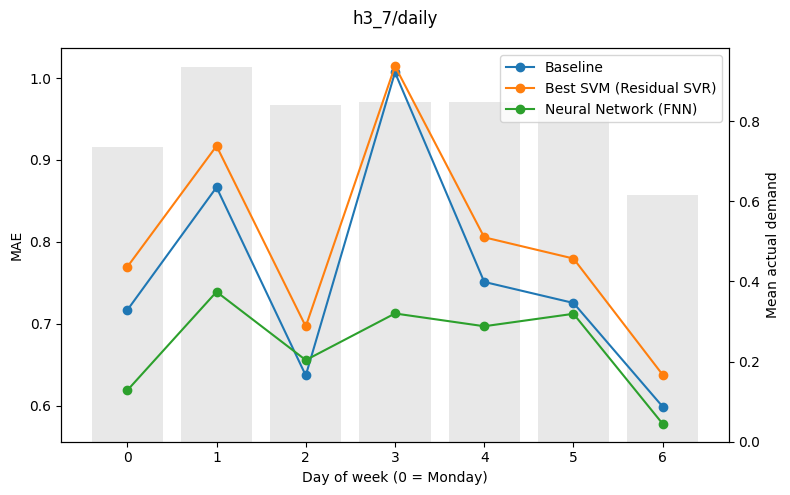

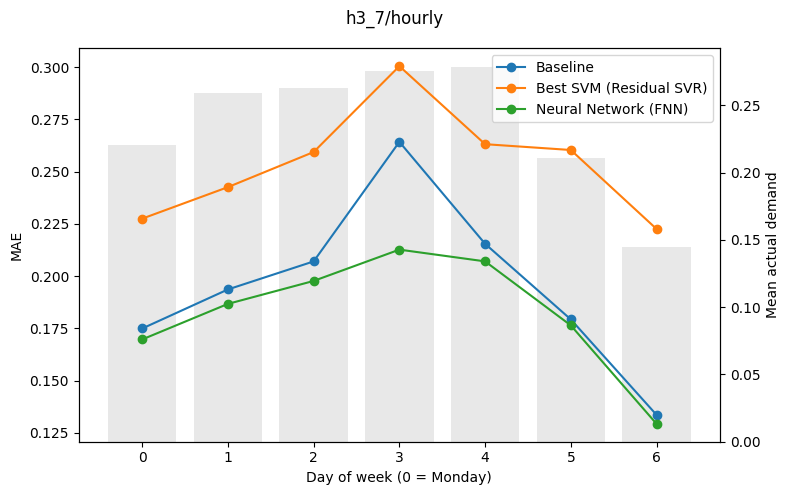

In [27]:
#| label: fig-svm-vs-nn-dayofweek
#| fig-cap: "Test MAE by day of week per temporal resolution."
for temporal, testing_df in comparisons.items():
    by_d = testing_df.groupby("day_of_week").apply(
        lambda g: pd.Series({
            "Baseline": mean_absolute_error(g[TRUTH], g[BASELINE_COL]),
            **{p["name"]: mean_absolute_error(g[TRUTH], g[p["col"]]) for p in predictions.values()},
            "mean_demand": g[TRUTH].mean(),
        }), include_groups=False)

    fig, ax = plt.subplots(figsize=(8, 5))
    fig.suptitle(f"h3_7/{temporal}")
    ax2 = ax.twinx()
    ax2.bar(by_d.index, by_d["mean_demand"], color="lightgray", alpha=0.5)
    ax2.set_ylabel("Mean actual demand")
    ax.plot(by_d.index, by_d["Baseline"], marker="o", label="Baseline")
    for p in predictions.values():
        ax.plot(by_d.index, by_d[p["name"]], marker="o", label=p["name"])
    ax.set_xlabel("Day of week (0 = Monday)")
    ax.set_ylabel("MAE")
    ax.set_xticks(range(7))
    ax.set_zorder(ax2.get_zorder() + 1)
    ax.patch.set_visible(False)
    ax.legend()
    plt.tight_layout()
    plt.show()

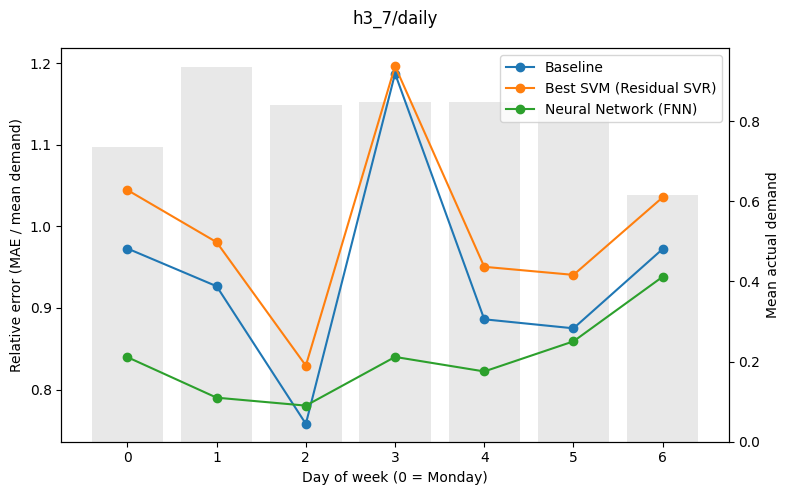

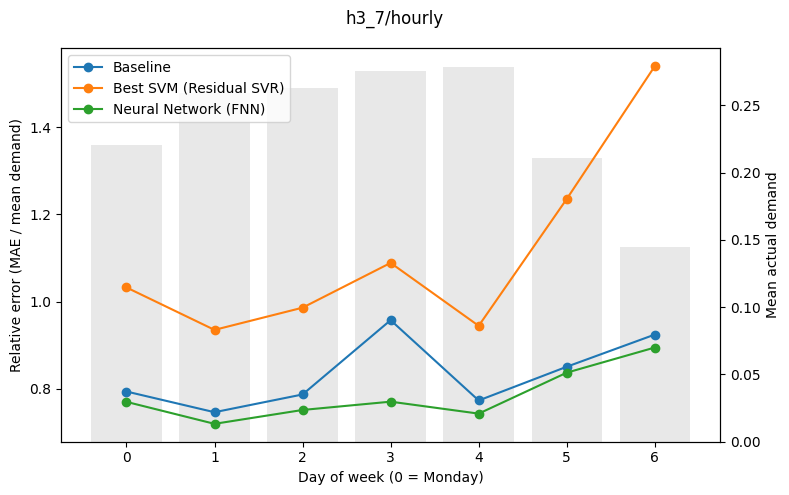

In [28]:
#| label: fig-svm-vs-nn-dayofweek-relerr
#| fig-cap: "Test relative error (MAE / mean demand) by day of week per temporal resolution."
for temporal, testing_df in comparisons.items():
    by_d = testing_df.groupby("day_of_week").apply(
        lambda g: pd.Series({
            "Baseline": mean_absolute_error(g[TRUTH], g[BASELINE_COL]) / g[TRUTH].mean(),
            **{p["name"]: mean_absolute_error(g[TRUTH], g[p["col"]]) / g[TRUTH].mean()
               for p in predictions.values()},
            "mean_demand": g[TRUTH].mean(),
        }), include_groups=False)

    fig, ax = plt.subplots(figsize=(8, 5))
    fig.suptitle(f"h3_7/{temporal}")
    ax2 = ax.twinx()
    ax2.bar(by_d.index, by_d["mean_demand"], color="lightgray", alpha=0.5)
    ax2.set_ylabel("Mean actual demand")
    ax.plot(by_d.index, by_d["Baseline"], marker="o", label="Baseline")
    for p in predictions.values():
        ax.plot(by_d.index, by_d[p["name"]], marker="o", label=p["name"])
    ax.set_xlabel("Day of week (0 = Monday)")
    ax.set_ylabel("Relative error (MAE / mean demand)")
    ax.set_xticks(range(7))
    ax.set_zorder(ax2.get_zorder() + 1)
    ax.patch.set_visible(False)
    ax.legend()
    plt.tight_layout()
    plt.show()

### Error throughout the day

Only H3_7/Hourly carries an hour_of_day feature, so this breakdown is hourly-only. It shows
whether errors concentrate around commute peaks (roughly 7-9 and 16-19) or overnight, when demand
is near zero and even small absolute misses can dominate relative error.

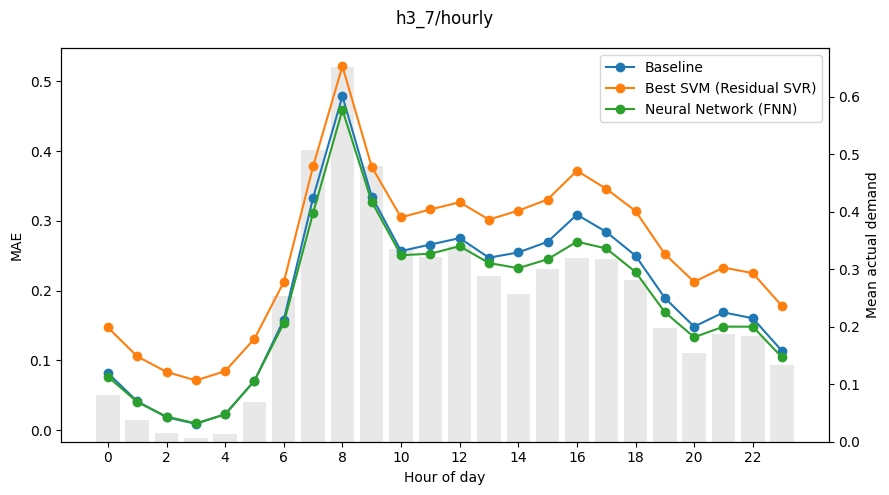

In [29]:
#| label: fig-svm-vs-nn-hourofday
#| fig-cap: "Test MAE by hour of day (h3_7/hourly)."
testing_df = comparisons["hourly"]
by_h = testing_df.groupby("hour_of_day").apply(
    lambda g: pd.Series({
        "Baseline": mean_absolute_error(g[TRUTH], g[BASELINE_COL]),
        **{p["name"]: mean_absolute_error(g[TRUTH], g[p["col"]]) for p in predictions.values()},
        "mean_demand": g[TRUTH].mean(),
    }), include_groups=False)

fig, ax = plt.subplots(figsize=(9, 5))
fig.suptitle("h3_7/hourly")
ax2 = ax.twinx()
ax2.bar(by_h.index, by_h["mean_demand"], color="lightgray", alpha=0.5)
ax2.set_ylabel("Mean actual demand")
ax.plot(by_h.index, by_h["Baseline"], marker="o", label="Baseline")
for p in predictions.values():
    ax.plot(by_h.index, by_h[p["name"]], marker="o", label=p["name"])
ax.set_xlabel("Hour of day")
ax.set_ylabel("MAE")
ax.set_xticks(range(0, 24, 2))
ax.set_zorder(ax2.get_zorder() + 1)
ax.patch.set_visible(False)
ax.legend()
plt.tight_layout()
plt.show()

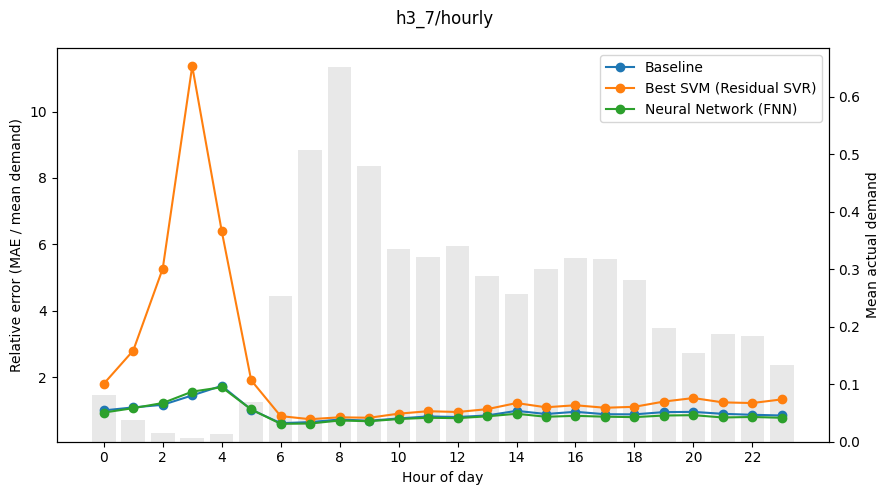

In [30]:
#| label: fig-svm-vs-nn-hourofday-relerr
#| fig-cap: "Test relative error (MAE / mean demand) by hour of day (h3_7/hourly)."
testing_df = comparisons["hourly"]
by_h = testing_df.groupby("hour_of_day").apply(
    lambda g: pd.Series({
        "Baseline": mean_absolute_error(g[TRUTH], g[BASELINE_COL]) / g[TRUTH].mean(),
        **{p["name"]: mean_absolute_error(g[TRUTH], g[p["col"]]) / g[TRUTH].mean()
           for p in predictions.values()},
        "mean_demand": g[TRUTH].mean(),
    }), include_groups=False)

fig, ax = plt.subplots(figsize=(9, 5))
fig.suptitle("h3_7/hourly")
ax2 = ax.twinx()
ax2.bar(by_h.index, by_h["mean_demand"], color="lightgray", alpha=0.5)
ax2.set_ylabel("Mean actual demand")
ax.plot(by_h.index, by_h["Baseline"], marker="o", label="Baseline")
for p in predictions.values():
    ax.plot(by_h.index, by_h[p["name"]], marker="o", label=p["name"])
ax.set_xlabel("Hour of day")
ax.set_ylabel("Relative error (MAE / mean demand)")
ax.set_xticks(range(0, 24, 2))
ax.set_zorder(ax2.get_zorder() + 1)
ax.patch.set_visible(False)
ax.legend()
plt.tight_layout()
plt.show()

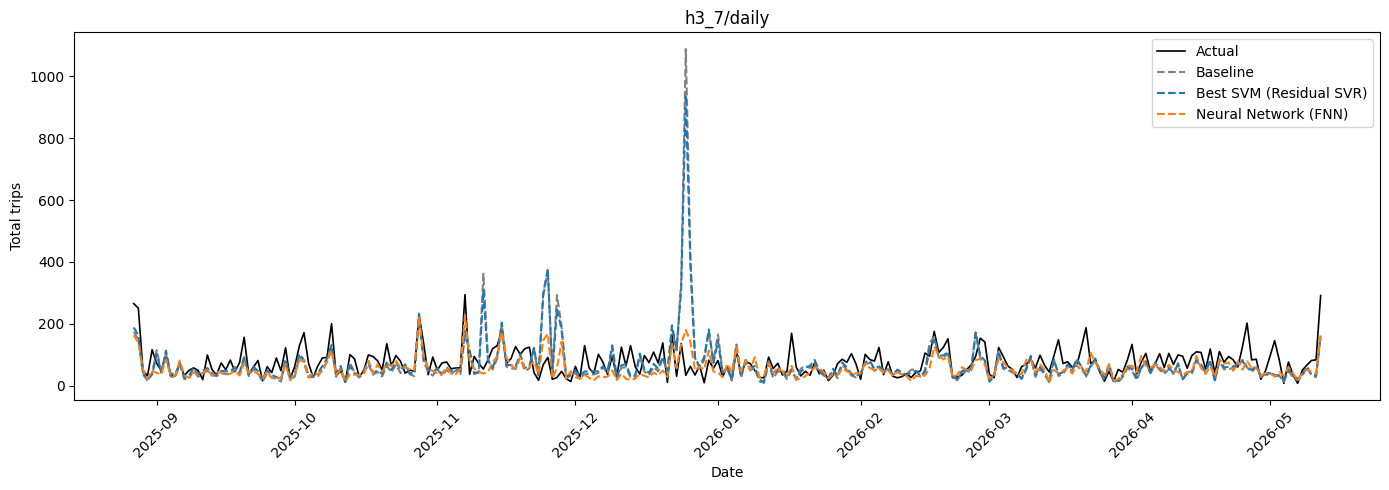

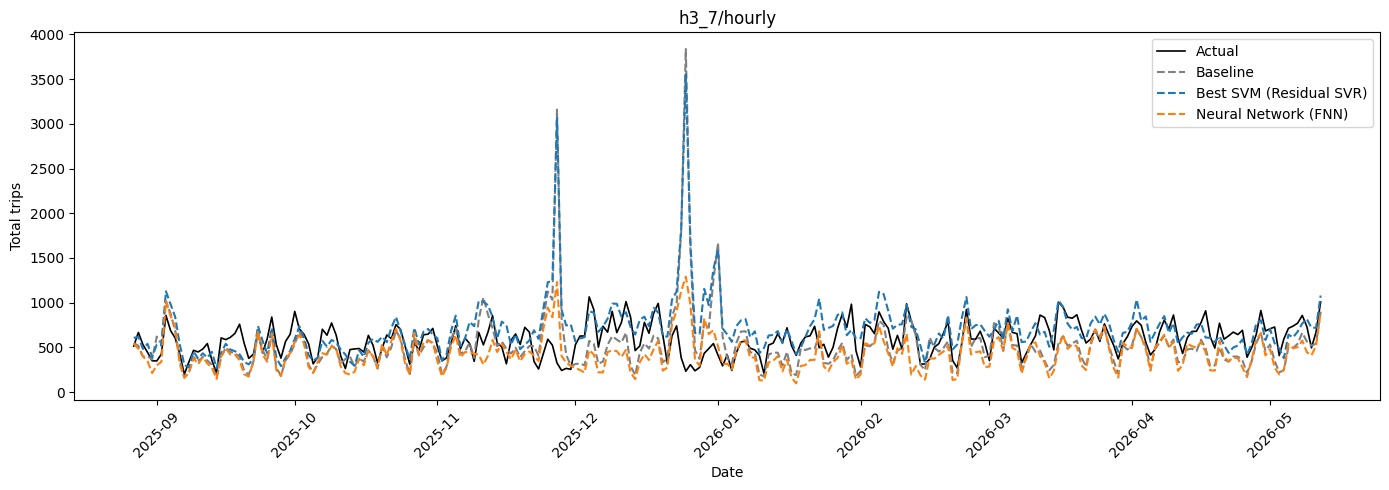

In [31]:
#| label: fig-svm-vs-nn-timeseries
#| fig-cap: "City-wide demand over the test period per temporal resolution."
for temporal, testing_df in comparisons.items():
    ts = testing_df.copy()
    ts["date"] = pd.to_datetime(ts["timestamp"]).dt.date
    daily_agg = ts.groupby("date").agg(
        actual=(TRUTH, "sum"),
        baseline=(BASELINE_COL, "sum"),
    ).reset_index()
    for p in predictions.values():
        daily_agg[p["name"]] = ts.groupby("date")[p["col"]].sum().values

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.set_title(f"h3_7/{temporal}")
    ax.plot(daily_agg["date"], daily_agg["actual"], label="Actual", color="black", linewidth=1.2)
    ax.plot(daily_agg["date"], daily_agg["baseline"], label="Baseline", linestyle="--", color="gray")
    for p in predictions.values():
        ax.plot(daily_agg["date"], daily_agg[p["name"]], label=p["name"], linestyle="--")
    ax.set_xlabel("Date")
    ax.set_ylabel("Total trips")
    ax.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## When does each model do best?

The maps above show *where* errors fall; this table shows *when*. It breaks test MAE down by
demand magnitude (zero / low / medium / high) and by weather (dry vs. rainy days), so a model that
wins overall but loses on, say, the busiest cells or on rainy days is not hidden behind a single
average. The same segmentation `3.6b` uses for the direct-vs-residual comparison.

In [32]:
#| label: tbl-svm-vs-nn-segments
#| fig-cap: "Test MAE, relative error, and skill score by demand band and weather per temporal resolution."
def segment_masks(df, y):
    df["is_rainy"] = (df["total_precip_mm"] >= 0.1).astype(int)
    return {
        "all": np.ones(len(df), dtype=bool),
        "zero demand (y = 0)": y == 0,
        "low demand (1-10)": (y >= 1) & (y <= 10),
        "medium demand (11-100)": (y > 10) & (y <= 100),
        "high demand (> 100)": y > 100,
        "dry days": df["is_rainy"].values == 0,
        "rainy days": df["is_rainy"].values == 1,
    }

def row_rel_error(y_true, y_pred):
    """Per-row relative error |y_true - y_pred| / y_true; undefined (NaN) where y_true == 0."""
    with np.errstate(divide="ignore", invalid="ignore"):
        rel = np.abs(y_true - y_pred) / y_true
    return np.where(y_true == 0, np.nan, rel)

segment_tables = {}
segment_order = {}
for temporal, testing_df in comparisons.items():
    print(f"\n--- h3_7/{temporal} ---")
    y_true = testing_df[TRUTH].values
    rel_err_rows = {"Baseline": row_rel_error(y_true, testing_df[BASELINE_COL].values)}
    for p in predictions.values():
        rel_err_rows[p["name"]] = row_rel_error(y_true, testing_df[p["col"]].values)

    rows = []
    for seg_name, mask in segment_masks(testing_df, y_true).items():
        if mask.sum() == 0:
            continue
        mean_actual = y_true[mask].mean()
        rows.append({"segment": seg_name, "Model": "Baseline", "n": int(mask.sum()),
                     "mean_actual": mean_actual,
                     "MAE": mean_absolute_error(y_true[mask], testing_df[BASELINE_COL].values[mask]),
                     "rel_error": np.nanmean(rel_err_rows["Baseline"][mask])})
        for p in predictions.values():
            rows.append({"segment": seg_name, "Model": p["name"], "n": int(mask.sum()),
                         "mean_actual": mean_actual,
                         "MAE": mean_absolute_error(y_true[mask], testing_df[p["col"]].values[mask]),
                         "rel_error": np.nanmean(rel_err_rows[p["name"]][mask])})
    seg_df = pd.DataFrame(rows)
    baseline_mae = seg_df.loc[seg_df["Model"] == "Baseline"].set_index("segment")["MAE"]
    # Skill score vs. the historical-mean baseline: 1 = perfect, 0 = ties baseline, < 0 = worse than baseline.
    seg_df["skill_score"] = 1 - seg_df["MAE"] / seg_df["segment"].map(baseline_mae)
    segment_tables[temporal] = seg_df
    segment_order[temporal] = seg_df["segment"].unique().tolist()
    display(seg_df.drop(columns="mean_actual").set_index(["segment", "Model"]).round(3))


--- h3_7/daily ---


n     MAE  rel_error  \
segment                Model                                               
all                    Baseline                 24068   0.756      1.296   
                       Best SVM (Residual SVR)  24068   0.802      1.242   
                       Neural Network (FNN)     24068   0.673      0.852   
zero demand (y = 0)    Baseline                 21771   0.120        NaN   
                       Best SVM (Residual SVR)  21771   0.183        NaN   
                       Neural Network (FNN)     21771   0.162        NaN   
low demand (1-10)      Baseline                  1767   3.734      1.495   
                       Best SVM (Residual SVR)   1767   3.565      1.424   
                       Neural Network (FNN)      1767   2.328      0.933   
medium demand (11-100) Baseline                   522  16.360      0.637   
                       Best SVM (Residual SVR)    522  16.447      0.639   
                       Neural Network (FNN)       522  15.521      0.584   
high demand (> 100)    Baseline                     8  56.753      0.354   
                       Best SVM (Residual SVR)      8  53.498      0.334   
                       Neural Network (FNN)         8  55.950      0.355   
dry days               Baseline                 21285   0.759      1.324   
                       Best SVM (Residual SVR)  21285   0.803      1.264   
                       Neural Network (FNN)     21285   0.677      0.853   
rainy days             Baseline                  2783   0.730      1.084   
                       Best SVM (Residual SVR)   2783   0.788      1.077   
                       Neural Network (FNN)      2783   0.641      0.841   

                                                skill_score  
segment                Model                                 
all                    Baseline                       0.000  
                       Best SVM (Residual SVR)       -0.060  
                       Neural Network (FNN)           0.110  
zero demand (y = 0)    Baseline                       0.000  
                       Best SVM (Residual SVR)       -0.528  
                       Neural Network (FNN)          -0.353  
low demand (1-10)      Baseline                       0.000  
                       Best SVM (Residual SVR)        0.045  
                       Neural Network (FNN)           0.376  
medium demand (11-100) Baseline                       0.000  
                       Best SVM (Residual SVR)       -0.005  
                       Neural Network (FNN)           0.051  
high demand (> 100)    Baseline                       0.000  
                       Best SVM (Residual SVR)        0.057  
                       Neural Network (FNN)           0.014  
dry days               Baseline                       0.000  
                       Best SVM (Residual SVR)       -0.058  
                       Neural Network (FNN)           0.109  
rainy days             Baseline                       0.000  
                       Best SVM (Residual SVR)       -0.078  
                       Neural Network (FNN)           0.122


--- h3_7/hourly ---


n     MAE  rel_error  \
segment                Model                                                
all                    Baseline                 643069   0.195      0.933   
                       Best SVM (Residual SVR)  643069   0.254      0.927   
                       Neural Network (FNN)     643069   0.183      0.848   
zero demand (y = 0)    Baseline                 619658   0.041        NaN   
                       Best SVM (Residual SVR)  619658   0.105        NaN   
                       Neural Network (FNN)     619658   0.029        NaN   
low demand (1-10)      Baseline                  19327   2.981      1.016   
                       Best SVM (Residual SVR)   19327   2.958      1.013   
                       Neural Network (FNN)      19327   2.804      0.904   
medium demand (11-100) Baseline                   4060  10.269      0.542   
                       Best SVM (Residual SVR)    4060   9.850      0.521   
                       Neural Network (FNN)       4060  10.912      0.585   
high demand (> 100)    Baseline                     24  32.722      0.261   
                       Best SVM (Residual SVR)      24  29.551      0.241   
                       Neural Network (FNN)         24  32.704      0.265   
dry days               Baseline                 565776   0.195      0.936   
                       Best SVM (Residual SVR)  565776   0.249      0.928   
                       Neural Network (FNN)     565776   0.181      0.845   
rainy days             Baseline                  77293   0.201      0.918   
                       Best SVM (Residual SVR)   77293   0.290      0.919   
                       Neural Network (FNN)      77293   0.197      0.867   

                                                skill_score  
segment                Model                                 
all                    Baseline                       0.000  
                       Best SVM (Residual SVR)       -0.298  
                       Neural Network (FNN)           0.065  
zero demand (y = 0)    Baseline                       0.000  
                       Best SVM (Residual SVR)       -1.553  
                       Neural Network (FNN)           0.286  
low demand (1-10)      Baseline                       0.000  
                       Best SVM (Residual SVR)        0.008  
                       Neural Network (FNN)           0.059  
medium demand (11-100) Baseline                       0.000  
                       Best SVM (Residual SVR)        0.041  
                       Neural Network (FNN)          -0.063  
high demand (> 100)    Baseline                       0.000  
                       Best SVM (Residual SVR)        0.097  
                       Neural Network (FNN)           0.001  
dry days               Baseline                       0.000  
                       Best SVM (Residual SVR)       -0.278  
                       Neural Network (FNN)           0.071  
rainy days             Baseline                       0.000  
                       Best SVM (Residual SVR)       -0.440  
                       Neural Network (FNN)           0.019

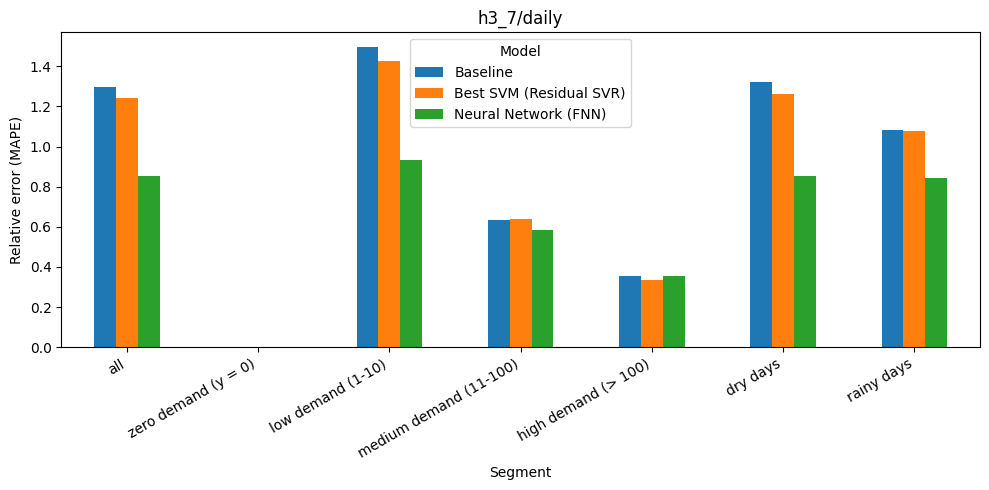

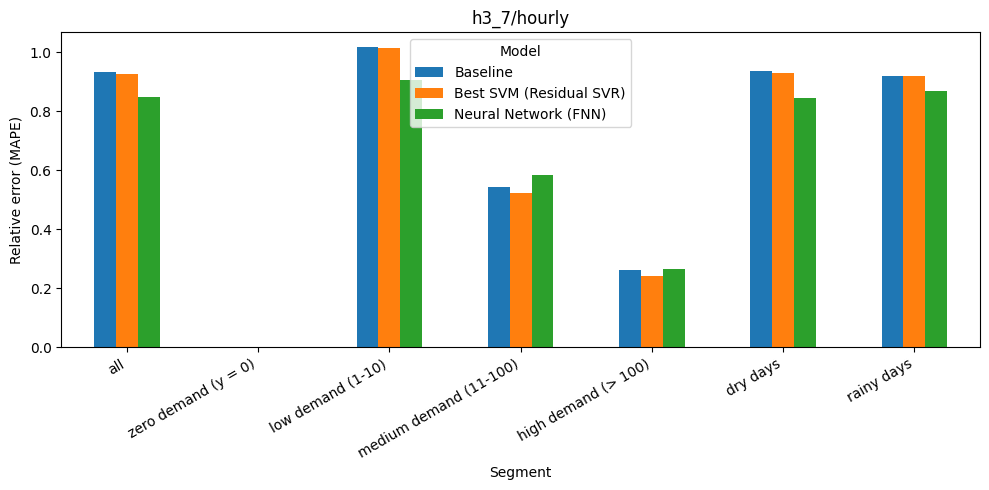

In [33]:
#| label: fig-svm-vs-nn-segments-relerr
#| fig-cap: "Test relative error (MAE / mean demand) by segment per temporal resolution."
model_order = ["Baseline"] + [p["name"] for p in predictions.values()]
for temporal, seg_df in segment_tables.items():
    pivot = seg_df.pivot(index="segment", columns="Model", values="rel_error")
    pivot = pivot.loc[segment_order[temporal], model_order]

    fig, ax = plt.subplots(figsize=(10, 5))
    pivot.plot(kind="bar", ax=ax)
    ax.set_title(f"h3_7/{temporal}")
    ax.set_xlabel("Segment")
    ax.set_ylabel("Relative error (MAPE)")
    ax.legend(title="Model")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()